# ***Trabalhando com Planilhas do Excel***

--------------------------------------------------------------------------------------------------

In [64]:
import pandas as pd
import openpyxl as xlsx
import matplotlib

Leituras dos arquivos e criação de cada dataframe (df):

In [3]:
df_aracaju = pd.read_excel('../datasets/Aracaju.xlsx',)
df_fortaleza = pd.read_excel('../datasets/Fortaleza.xlsx',)
df_natal = pd.read_excel('../datasets/Natal.xlsx',)
df_recife = pd.read_excel('../datasets/Recife.xlsx',)
df_salvador = pd.read_excel('../datasets/Salvador.xlsx',)

In [4]:
# Testando um df:
df_fortaleza 

,Cidade,Data,Vendas,LojaID,Qtde
0,Fortaleza,2019-01-01,45.27,1002,2
1,Fortaleza,2019-01-01,115.61,1002,3
2,Fortaleza,2019-02-10,35.33,1004,3
3,Fortaleza,2019-02-10,20.95,1004,6
4,Fortaleza,2019-01-01,14.25,1004,6
...,...,...,...,...,...
137,Fortaleza,2019-03-02,51.99,983,3
138,Fortaleza,2019-03-02,150.38,983,6
139,Fortaleza,2019-03-02,141.16,980,7
140,Fortaleza,2019-03-02,166.89,983,5


--------------------------------------------------------------------------------------------------

# ***Unindo todos os valores de cada dataframe***

--------------------------------------------------------------------------------------------------

É possível juntar 'df' utilizando o método concat()

## concat()

É necessário que dentro de seus parâmetros, coloquemos dentro de uma lista os dataframes queremos concatenar.

In [5]:
df = pd.concat([df_aracaju, df_fortaleza, df_natal, df_recife, df_salvador])

## head()

In [6]:
# Checando o dataframe final:
df.head(21)

,Cidade,Data,Vendas,LojaID,Qtde
0,Aracaju,2018-01-01,142.00,1520,1
1,Aracaju,2018-01-01,14.21,1522,6
2,Aracaju,2018-01-01,71.55,1520,1
3,Aracaju,2018-01-01,3.01,1521,7
4,Aracaju,2018-01-01,24.51,1522,8
5,Aracaju,2018-01-01,156.20,1522,1
6,Aracaju,2018-01-01,35.50,1522,2
7,Aracaju,2019-01-01,172.22,1522,6
8,Aracaju,2019-01-01,12.16,1523,1
9,Aracaju,2019-01-01,149.36,1523,3


## tail()

In [7]:
df.tail(20)

,Cidade,Data,Vendas,LojaID,Qtde
220,Salvador,2019-01-02,42.71,1035,1
221,Salvador,2019-01-02,142.23,1035,2
222,Salvador,2019-01-02,43.96,1037,1
223,Salvador,2019-01-02,40.51,1037,2
224,Salvador,2019-01-02,178.30,1035,3
225,Salvador,2019-01-02,36.23,1035,1
226,Salvador,2019-01-02,38.32,1035,2
227,Salvador,2019-01-02,14.70,1035,1
228,Salvador,2019-01-02,6.87,1037,3
229,Salvador,2019-01-02,43.08,1036,2


--------------------------------------------------------------------------------------------------

# ***Amostra de Dados - Pegar partes do arquivo***

--------------------------------------------------------------------------------------------------

## Resquisitando ao Pandas trazer uma amostra do arquivo

### sample()

'sample' eng. para 'amostra'

Por padrão ele retorna as colunas e uma linha de toda a tabela, sendo assim ele traz uma 'amostra' do que há no arquivo.

Se quiser, coloque o número de linhas que gostaria de trazer como parâmetros.

In [11]:
df.sample()

,Cidade,Data,Vendas,LojaID,Qtde
2,Recife,2019-02-10,12.94,983,5


In [12]:
df.sample(5)

,Cidade,Data,Vendas,LojaID,Qtde
63,Aracaju,2018-01-01,39.87,1522,5
52,Natal,2018-04-27,778.00,854,4
46,Recife,2019-01-01,239.17,981,8
150,Natal,2019-01-02,11.13,1035,2
139,Natal,2019-01-02,169.01,1036,1


--------------------------------------------------------------------------------------------------

# ***Alterando um tipo de dado já definido***

--------------------------------------------------------------------------------------------------

Primeiro, vamos utilizar um método que nos informa qual é o tipo de dado que cada coluna armazena:

### dtypes()

Método utilizado para retornar informações de tipo para cada coluna., informado o que ela está armazenando pelo tipo de dado.

Obs.: Não há necessidade de colocar ' () '

In [13]:
df.dtypes

Cidade            object
Data      datetime64[ns]
Vendas           float64
LojaID             int64
Qtde               int64
dtype: object

Agora que sabemos quais são os tipos de dados de cada um, vamos alterar o seu tipo de um deles, neste caso vamos escolher "LojaID" (segundo a professora), pois não iremos fazer cálculos com ele:

## ***Alterando dados***

### astype()

Altera o tipo de um dado para outro.

Obs.: Perceba que isso não deve mudar os valores contidos nas linhas de cada coluna.

In [14]:
df["LojaID"] = df["LojaID"].astype("object")

Vamos confirmar se houve a alteração:

In [15]:
df.dtypes

Cidade            object
Data      datetime64[ns]
Vendas           float64
LojaID            object
Qtde               int64
dtype: object

Alteração finalizada. Houve a mudança de 'int64' para 'object'.

--------------------------------------------------------------------------------------------------

# ***Valores Null - Nulos***

--------------------------------------------------------------------------------------------------

É possível descobrir se há valores 'null' (nulos) em nosso arquivo:

### isnull()

Método que retorna se há valores nulos em cada linha do arquivo.

In [16]:
df.isnull()

,Cidade,Data,Vendas,LojaID,Qtde
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
235,False,False,False,False,False
236,False,False,False,False,False
237,False,False,False,False,False
238,False,False,False,False,False


Perceba que quando fazemos isso, ele retorna cada linha e diz se o há nela é nulo (True) ou não (False).

É interessante utilizamos dessa forma:

### isnull() + sum()

In [17]:
df.isnull().sum()

Cidade    0
Data      0
Vendas    0
LojaID    0
Qtde      0
dtype: int64

Estamos dizendo: "Se há valores nulos, retorne a soma de cada um deles em cada coluna".

--------------------------------------------------------------------------------------------------

## ***Se há valores nulos, podemos alterar isso:***

### ***Alterando nulos para Média***

### fillna() + inplace = True

Suponhamos que em 'Vendas' houvesse valores nulos, fariamos da seguinte maneira: 

In [ ]:
df["Vendas"].fillna(df["Vendas"].mean(), inplace = True)

Lembre-se de utilizar os ensinamentos passado para chegar se a aleração foi concluída.

Obs.: Não executaremos o código pois não há valore nulos em nosso arquivo de estudo.

### ***Alterando nulos para zero***

In [ ]:
df["Vendas"].fillna(0 , inplace = True)

### ***Apagando - as linhas com nulos***

### dropna() + inplace = True

In [ ]:
df.dropna(inplace = True)

Obs.: Não executaremos o código pois não há valore nulos em nosso arquivo de estudo.

### ***Apagando - as linhas com nulos se baseando em uma das colunas***

### dropna() + subset =

In [ ]:
df.dropna(subset = ["Vendas"], inplace= True)

### ***Apagando - linhas que estejam com valores faltantes sem todas as colunas***

### dropna() + how =

In [ ]:
df.dropna(how = "all", inplace= True)

--------------------------------------------------------------------------------------------------

# ***Criando colunas novas***

--------------------------------------------------------------------------------------------------

### mul() 


Método que permite a criação de uma nova coluna feita por meio da multiplicação (mul) de duas outras colunas existentes.

Vamos criar a nova coluna "Receita" que será a multiplicação de "Vendas" * "Qtde".

In [19]:
df["Receita"] = df["Vendas"].mul(df["Qtde"])

Confirmando a criação:

In [21]:
df.head()

,Cidade,Data,Vendas,LojaID,Qtde,Receita
0,Aracaju,2018-01-01,142.00,1520,1,142.00
1,Aracaju,2018-01-01,14.21,1522,6,85.26
2,Aracaju,2018-01-01,71.55,1520,1,71.55
3,Aracaju,2018-01-01,3.01,1521,7,21.07
4,Aracaju,2018-01-01,24.51,1522,8,196.08


Suponhamos que estivessemos em uma situação diferente: Ao invés de não termos "Receitas", não teriamos "Qtde".

A lógica é a mesma, mas a operação seria diferente por conta da forma verdadeira de chegarmos ao número de itens por meio dessa mesma formula:

In [ ]:
#df["Receita/Vendas"] = df["Receita"] / df["Vendas"]

Obs: Não iremos inciar o código pois já temos "Qtde".

Entao é como se dissessemos: "o dataframe recebe["nome da nova coluna"] = com o dataframe[" Receita "] divida por dataframe[" Vendas "]

--------------------------------------------------------------------------------------------------

# ***Retornando o MAIOR número de uma coluna/receita***

--------------------------------------------------------------------------------------------------

### max()

Método que retorna o MAIOR número em uma coluna.

In [22]:
df["Receita"].max()

np.float64(3544.0)

--------------------------------------------------------------------------------------------------

# ***Retornando o MENOR número de uma coluna/receita***

--------------------------------------------------------------------------------------------------

### min()

Método que retorna o MENOR número em uma coluna.

In [23]:
df["Receita"].min()

np.float64(3.34)

é possível também vermos o dia mais antigo com min():

In [39]:
df["Data"].min()

Timestamp('2018-01-01 00:00:00')

--------------------------------------------------------------------------------------------------

# ***Retornando os Top MAIORES valores***

--------------------------------------------------------------------------------------------------

### nlargest()

Método para cituações em que seja necessário trazer os maiores valores, de acordo com o parâmetro dado.

In [24]:
df.nlargest(3, "Receita") # Ou seja, me traga os TOP 3 maiores valores da 'Receita' que há.

,Cidade,Data,Vendas,LojaID,Qtde,Receita
7,Natal,2019-03-18,886.0,853,4,3544.0
51,Natal,2018-01-21,859.0,852,4,3436.0
55,Natal,2019-01-08,859.0,854,4,3436.0


--------------------------------------------------------------------------------------------------

# ***Retornando os Top MENORES valores***

--------------------------------------------------------------------------------------------------

### nsmallest()

Método para cituações em que seja necessário trazer os MENORES valores, de acordo com o parâmetro dado.

In [26]:
df.nsmallest(5, "Receita") # Ou seja, me traga os TOP 5 menores valores da 'Receita' que há.

,Cidade,Data,Vendas,LojaID,Qtde,Receita
118,Aracaju,2018-01-01,3.34,1522,1,3.34
65,Recife,2019-01-01,4.01,981,1,4.01
92,Natal,2019-01-02,4.57,1035,1,4.57
92,Salvador,2019-01-01,4.57,1035,1,4.57
95,Natal,2019-01-02,5.13,1035,1,5.13


--------------------------------------------------------------------------------------------------

# ***Agrupamento - Por cidade***

--------------------------------------------------------------------------------------------------

### groupby()

Obs.: Utilizaremos o método sum() para auxiliar no agrupamento por cidade.

In [28]:
df.groupby("Cidade")["Receita"].sum() # ou seja, agrupe por cidade e então, traga a receita somada de cada um.

Cidade
Aracaju       48748.25
Fortaleza     37913.97
Natal        167227.52
Recife        51936.51
Salvador      40596.73
Name: Receita, dtype: float64

--------------------------------------------------------------------------------------------------

# ***Ordenando - o conjunto de dados***

--------------------------------------------------------------------------------------------------

### sort_values()

Obs.: Utilizaremos ascending e o método head().

In [29]:
df.sort_values("Receita", ascending= False).head(10)

,Cidade,Data,Vendas,LojaID,Qtde,Receita
7,Natal,2019-03-18,886.0,853,4,3544.0
55,Natal,2019-01-08,859.0,854,4,3436.0
51,Natal,2018-01-21,859.0,852,4,3436.0
30,Natal,2018-10-02,856.0,853,4,3424.0
41,Natal,2018-05-20,835.0,852,4,3340.0
10,Natal,2018-10-27,828.0,852,4,3312.0
38,Natal,2018-02-25,828.0,852,4,3312.0
69,Natal,2019-03-24,817.0,852,4,3268.0
62,Natal,2018-02-10,793.0,854,4,3172.0
52,Natal,2018-04-27,778.0,854,4,3112.0


--------------------------------------------------------------------------------------------------

# ***Criando uma nova coluna com o ano***

--------------------------------------------------------------------------------------------------

In [30]:
df["Ano_Venda"] = df["Data"].dt.year

In [31]:
df.head(5)

,Cidade,Data,Vendas,LojaID,Qtde,Receita,Ano_Venda
0,Aracaju,2018-01-01,142.00,1520,1,142.00,2018
1,Aracaju,2018-01-01,14.21,1522,6,85.26,2018
2,Aracaju,2018-01-01,71.55,1520,1,71.55,2018
3,Aracaju,2018-01-01,3.01,1521,7,21.07,2018
4,Aracaju,2018-01-01,24.51,1522,8,196.08,2018


--------------------------------------------------------------------------------------------------

# ***Filtrando - Extraindo o mês e o dia***

--------------------------------------------------------------------------------------------------

In [33]:
df["mes_venda"], df["dia_venda"] = (df["Data"].dt.month, df["Data"].dt.day)

ou seja, dizemos:

crie "mes_venda" e "dia_venda" = utilize a coluna "Data" no dataframe; utilize o método "month" do pandas em "mes_venda" , utilize a coluna "Data" no dataframe; utilize o método "day" do pandas em "dia_venda"

In [49]:
df.sample(5)

,Cidade,Data,Vendas,LojaID,Qtde,Receita,Ano_Venda,mes_venda,dia_venda,diferenca_dias
52,Aracaju,2018-01-01,14.76,1520,3,44.28,2018,1,1,0 days
99,Natal,2019-01-02,40.38,1037,1,40.38,2019,1,2,366 days
232,Salvador,2019-01-03,167.76,1034,3,503.28,2019,1,3,367 days
4,Salvador,2019-02-14,19.47,1037,3,58.41,2019,2,14,409 days
188,Natal,2019-01-02,178.11,1035,3,534.33,2019,1,2,366 days


--------------------------------------------------------------------------------------------------

## ***Filtrando - as vendas de 2019 do mês de março***

In [58]:
vendas_marco_19 = df.loc[(df["Data"].dt.year == 2019) & (df["Data"].dt.month == 3)]

In [ ]:
# Chamamos a variável que criamos acima:
vendas_marco_19

,Cidade,Data,Vendas,LojaID,Qtde,Receita,Ano_Venda,mes_venda,dia_venda,diferenca_dias,trimestre_venda
108,Fortaleza,2019-03-02,152.89,981,4,611.56,2019,3,2,425 days,1
109,Fortaleza,2019-03-02,18.90,982,6,113.40,2019,3,2,425 days,1
110,Fortaleza,2019-03-02,51.98,983,6,311.88,2019,3,2,425 days,1
111,Fortaleza,2019-03-02,8.00,981,3,24.00,2019,3,2,425 days,1
112,Fortaleza,2019-03-02,133.59,982,1,133.59,2019,3,2,425 days,1
...,...,...,...,...,...,...,...,...,...,...,...
137,Salvador,2019-03-02,51.66,1036,3,154.98,2019,3,2,425 days,1
138,Salvador,2019-03-02,212.03,1037,3,636.09,2019,3,2,425 days,1
139,Salvador,2019-03-02,169.01,1036,1,169.01,2019,3,2,425 days,1
140,Salvador,2019-03-02,20.79,1036,2,41.58,2019,3,2,425 days,1


--------------------------------------------------------------------------------------------------

# ***Calculando - Como saber a diferença de dias***

--------------------------------------------------------------------------------------------------

Armanzenaremos o resultado em uma nova coluna:

In [42]:
df["diferenca_dias"] = df["Data"] - df["Data"].min()

## Calculando - Criando a coluna trimestre

### dt.quarter

- acessor: dt
- atributo ou parametro: quarter

In [50]:
df["trimestre_venda"] = df["Data"].dt.quarter

In [57]:
df.sample(20)

,Cidade,Data,Vendas,LojaID,Qtde,Receita,Ano_Venda,mes_venda,dia_venda,diferenca_dias,trimestre_venda
63,Salvador,2019-01-01,166.59,1036,1,166.59,2019,1,1,365 days,1
8,Recife,2019-02-11,56.47,980,6,338.82,2019,2,11,406 days,1
4,Salvador,2019-02-14,19.47,1037,3,58.41,2019,2,14,409 days,1
42,Aracaju,2018-01-01,40.00,1520,8,320.00,2018,1,1,0 days,1
116,Natal,2019-01-02,41.78,1034,3,125.34,2019,1,2,366 days,1
203,Salvador,2019-01-02,37.75,1035,2,75.50,2019,1,2,366 days,1
151,Natal,2019-01-02,14.63,1035,1,14.63,2019,1,2,366 days,1
49,Aracaju,2018-01-01,53.74,1522,3,161.22,2018,1,1,0 days,1
33,Recife,2019-01-01,32.33,982,1,32.33,2019,1,1,365 days,1
75,Natal,2019-03-30,706.00,854,2,1412.00,2019,3,30,453 days,1


--------------------------------------------------------------------------------------------------

# ***VISUALIZAÇÃO DE DADOS***

--------------------------------------------------------------------------------------------------

In [61]:
df["LojaID"].value_counts(ascending= False)

LojaID
1036    117
1035    112
1037    101
1034     67
983      65
982      44
1522     41
1520     39
980      36
981      31
1002     30
1005     30
1523     29
852      29
854      28
1004     28
853      26
1521     21
1003     20
Name: count, dtype: int64

Agora fazermos esses resultados em 'Gráfico de barras':

--------------------------------------------------------------------------------------------------

## ***Gráfico de barras***

<Axes: xlabel='LojaID'>

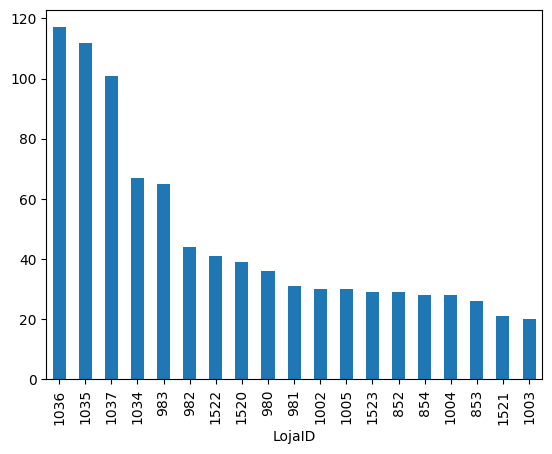

In [66]:
df["LojaID"].value_counts(ascending= False).plot.bar()

## ***Gráfico - Barras horizontais***

<Axes: ylabel='LojaID'>

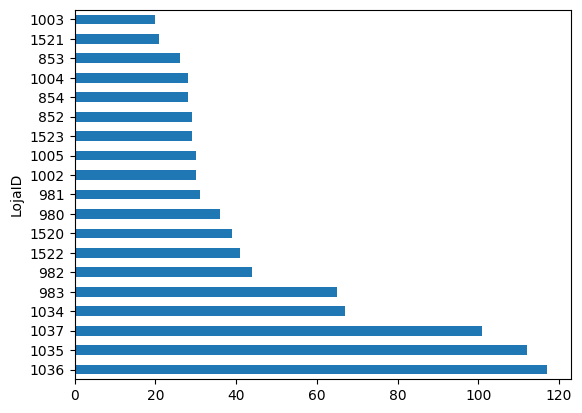

In [65]:
df["LojaID"].value_counts().plot.barh()